In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
import numpy as np

sys.path.append(os.path.abspath('../src'))
from DataTreatment import DataTreatment
from KNN import KNN
from CrossValidation import CrossValidation
from LogisticRegression import LogisticRegression

In [2]:
# Reading the data set
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
gender_submission = pd.read_csv('../data/gender_submission.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


$\textbf{Exploration}$

In [3]:
print(train.isna().sum())
print(train.shape)
train.describe(include='all')

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


It seems like columns PassengerId, Name and Cabin can be dropped, since they don't give us relevant information, or have too many Nans.

$\textbf{Data Treatment}$

1- Drop columns PassengerId, Name, Cabin

2- We'll replace all the $Nans$ by the column's most frequent value

3- Create a column named Ticket_score, which is the proportion of people with the same ticket prefix that survived

4- Standardize the data ((data-mean) / std) .

In [4]:
data_treatment = DataTreatment(train)
train_processed = data_treatment.get_processed_data()
train_processed.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Ticket_freq,Ticket_score,Survived
0,0.826913,-0.497514,0.432550,-0.473408,-0.502163,0.737281,-0.30739,0.615493,-0.578837,-2.089977,0
1,-1.565228,0.714647,0.432550,-0.473408,0.786404,-1.354813,-0.30739,-1.622891,-0.578837,1.959819,1
2,0.826913,-0.194474,-0.474279,-0.473408,-0.488580,-1.354813,-0.30739,0.615493,-0.578837,0.855329,1
3,-1.565228,0.487367,0.432550,-0.473408,0.420494,-1.354813,-0.30739,0.615493,0.155841,-0.002796,1
4,0.826913,0.487367,-0.474279,-0.473408,-0.486064,0.737281,-0.30739,0.615493,-0.578837,-0.002796,0


$\textbf{Prediction}$

$\textbf{KKN Predictor}$

We'll start with the KNN method

In [5]:
k = 1
knn = KNN(train)
knn.process_test_data(test)
test_y = knn.predict((k,))
test_y

,PassengerId,Survived
0,892,0.0
1,893,0.0
2,894,0.0
3,895,0.0
4,896,0.0
...,...,...
413,1305,0.0
414,1306,1.0
415,1307,0.0
416,1308,0.0


Using k = 1 is a very naive approach. To know the best k, we must use cross validation and pick the value that corresponds to the lowest test error rate

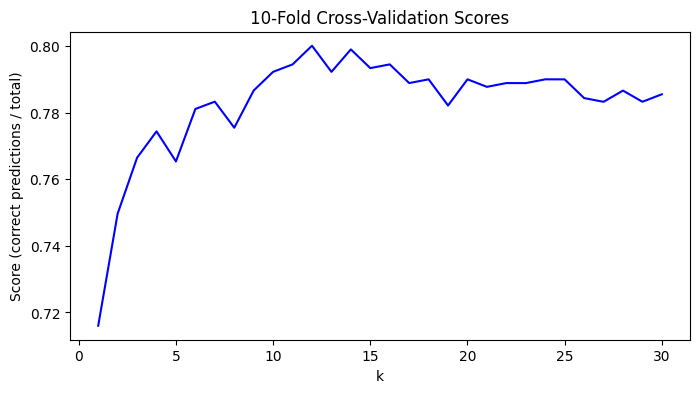

In [6]:
ks = [(k,) for k in range(1, 31)]
cv = CrossValidation(train, model="KNN")
scores = cv.cross_validate(hyper_params=ks)
scores_keys = [key[0] for key in scores.keys()]

fig = plt.figure(figsize=(8, 4))
plt.plot(scores_keys, scores.values(), color='blue')
plt.title('10-Fold Cross-Validation Scores')
plt.xlabel('k')
plt.ylabel('Score (correct predictions / total)')
plt.show()

The best score happens for k=12

In [7]:
k = 12
knn = KNN(train)
knn.process_test_data(test)
test_y = knn.predict((k,))
test_y['Survived'] = test_y['Survived'].astype(int)
survival_pct = 100 * test_y.sum()['Survived']/test_y.shape[0]
print('Survival percentage: ', survival_pct, "%")

Survival percentage:  32.535885167464116 %


In [8]:
#test_y.to_csv('../data/submission_knn.csv', index=False)

More prediction models coming soon...

$\textbf{Logistic Regression}$

In [9]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

In [10]:
log_reg = LogisticRegression(train)
log_reg.process_test_data(test)
test_y = log_reg.predict()
test_y['Survived'] = test_y['Survived'].astype(int)
test_y

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
C:\Users\felip\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_rati

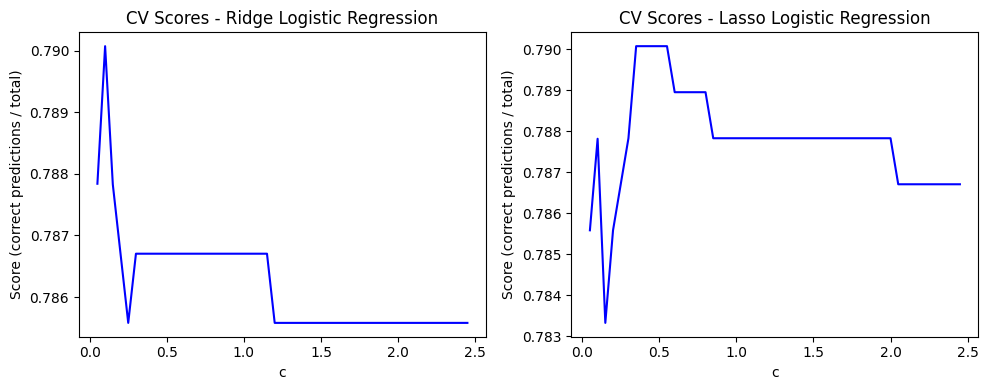

No Regularization CV score:  0.7855805243445693


In [39]:
l1_ratios = [0, 1]
cs = [c/20 for c in range(1, 50)] + [np.inf]
hyper_params = list(product(l1_ratios, cs))

cv = CrossValidation(train, model="Logistic Regression")
scores = cv.cross_validate(hyper_params)

scores_l1, scores_l2, scores_noreg = {}, {}, {}
for k, v in scores.items():
    if k[-1] == np.inf:
        scores_noreg[k[0]] = v
    elif k[0] == 0:
        scores_l2[k[1]] = v
    else:
        scores_l1[k[1]] = v


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(scores_l2.keys(), scores_l2.values(), color='blue')
axes[0].set_title("CV Scores - Ridge Logistic Regression")
axes[0].set_xlabel('c')
axes[0].set_ylabel('Score (correct predictions / total)')
axes[1].plot(scores_l1.keys(), scores_l1.values(), color='blue')
axes[1].set_title("CV Scores - Lasso Logistic Regression")
axes[1].set_xlabel('c')
axes[1].set_ylabel('Score (correct predictions / total)')
plt.tight_layout()
plt.show()
print("No Regularization CV score: ", np.mean(list(scores_noreg.values())))

Ridge regression with c = 0.1 and Lasso refression with c = 0.5 give us the best out of sample scores. Let's use Ridge with c = 0.1, since ridge preserves all variables

In [41]:
log_reg = LogisticRegression(train)
log_reg.process_test_data(test)
test_y = log_reg.predict(params=(0, 0.1))
test_y['Survived'] = test_y['Survived'].astype(int)
test_y

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [43]:
#test_y.to_csv('../data/submission_logistic_regression.csv', index=False)